In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df = pd.read_csv("dataset.csv")
df.head()

,State,Crop,Soil_Type,Fertilizer,N,P,K,Rainfall_mm,Temperature_C,Yield_kg_per_acre,Soil_pH,Year
0,Karnataka,Soybean,Loamy,DAP,96,41,51,123,31.06,1899,6.82,2003
1,Odisha,Cotton,Red Soil,Urea,29,36,112,247,33.97,1002,6.41,2002
2,Punjab,Groundnut,Red Soil,Compost,37,38,177,142,24.21,1465,7.06,2015
3,Gujarat,Wheat,Red Soil,Compost,58,77,129,227,30.85,2273,5.93,2022
4,Andhra Pradesh,Cotton,Clay,Organic,108,61,63,263,37.81,1497,6.24,2017


In [23]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   State              1500 non-null   object 
 1   Crop               1500 non-null   object 
 2   Soil_Type          1500 non-null   object 
 3   Fertilizer         1500 non-null   object 
 4   N                  1500 non-null   int64  
 5   P                  1500 non-null   int64  
 6   K                  1500 non-null   int64  
 7   Rainfall_mm        1500 non-null   int64  
 8   Temperature_C      1500 non-null   float64
 9   Yield_kg_per_acre  1500 non-null   int64  
 10  Soil_pH            1500 non-null   float64
 11  Year               1500 non-null   int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 140.8+ KB


,N,P,K,Rainfall_mm,Temperature_C,Yield_kg_per_acre,Soil_pH,Year
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,73.438000,61.282667,102.112667,176.806000,28.148547,7881.892667,6.766347,2012.090000
std,37.756932,33.257422,54.362863,73.776182,5.783160,20073.333665,0.724898,7.393218
min,10.000000,5.000000,10.000000,50.000000,18.020000,502.000000,5.500000,2000.000000
25%,41.000000,33.000000,56.000000,113.000000,23.132500,1202.750000,6.120000,2005.000000
50%,70.000000,61.000000,100.000000,176.000000,28.490000,1673.500000,6.795000,2012.000000
75%,106.000000,91.000000,149.000000,242.000000,33.180000,2571.750000,7.400000,2019.000000
max,139.000000,119.000000,199.000000,299.000000,37.960000,89946.000000,8.000000,2024.000000


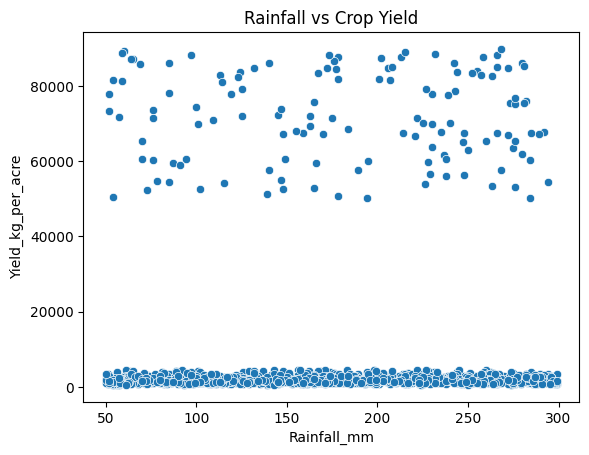

In [25]:
sns.scatterplot(x='Rainfall_mm', y='Yield_kg_per_acre', data=df)
plt.title("Rainfall vs Crop Yield")
plt.show()

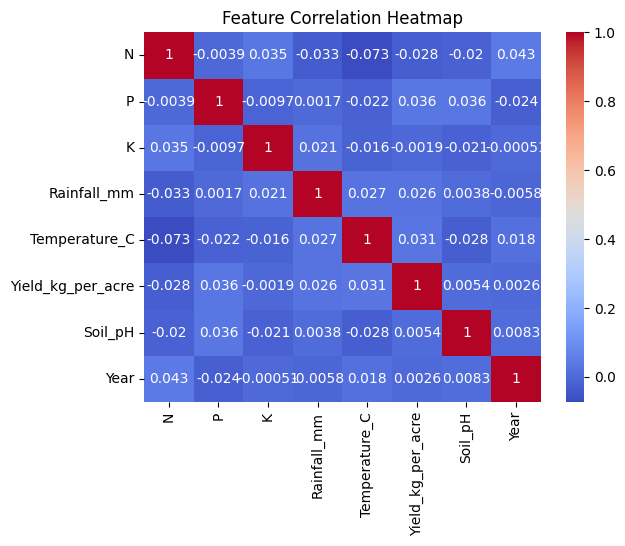

In [26]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [28]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Soil_Type'] = encoder.fit_transform(df['Soil_Type'])
df['Crop'] = encoder.fit_transform(df['Crop'])

In [29]:
df['npk_total'] = df['N'] + df['P'] + df['K']

In [31]:
df['growing_season_index'] = (df['Rainfall_mm'] * df['Temperature_C']) / 100

In [33]:
df['heat_days'] = df['Temperature_C'].apply(lambda x: 1 if x > 35 else 0)

In [34]:
df.head()

,State,Crop,Soil_Type,Fertilizer,N,P,K,Rainfall_mm,Temperature_C,Yield_kg_per_acre,Soil_pH,Year,npk_total,growing_season_index,heat_days
0,Karnataka,7,2,DAP,96,41,51,123,31.06,1899,6.82,2003,188,38.2038,0
1,Odisha,1,3,Urea,29,36,112,247,33.97,1002,6.41,2002,177,83.9059,0
2,Punjab,2,3,Compost,37,38,177,142,24.21,1465,7.06,2015,252,34.3782,0
3,Gujarat,9,3,Compost,58,77,129,227,30.85,2273,5.93,2022,264,70.0295,0
4,Andhra Pradesh,1,1,Organic,108,61,63,263,37.81,1497,6.24,2017,232,99.4403,1
